# Vorticity and MLD in the ice edge

According to [Gupta et al (2020)](https://agupubs.onlinelibrary.wiley.com/doi/full/10.1029/2020JC016404) the surface stress of anticyclonic eddies over the static sea ice can drive Ekman suction within the Anticyclonic eddies, thus decreasing the MLD within eddies and bringing warmer waters closer to the surface. THis process is called by the authors Eddy-Ice-Pumping (EIP).


This leads to a question on wether a higher presence of eddies in the sea ice border of models with ghigher resolution could make sea ice thinner, and reduce the sea ice extent. We want to test if that is what is causing changes in the SIC in our panan simulations. 



THis notebook will test that by binning the mixed layer depth in the panan's into vorticity bins, withing the sea ice edge, to see if we have lower mxed layer depths in locations of more negative vorticity (more anicyclonicity)


In [1]:
import intake
import matplotlib.pyplot as plt
import numpy as np
import netCDF4 as nc
import cartopy.crs as ccrs
import cf_xarray as cf
import xarray as xr
import cmocean.cm as cmocean
import glob
from mpl_toolkits.axes_grid1 import make_axes_locatable
import shutil as shutil
from dask.distributed import Client


In [2]:
client = Client(threads_per_worker = 1)

In [3]:
catalog = intake.cat.access_nri

In [4]:
Month_inds = slice(8,10)
Month_inds_array = [8,9,10]
time_slice=slice('2000-01','2000-12')
lat_slice=slice(-85,-50)


#### Importing surface vorticity

In [5]:
#importing EKE panan01 during winter
dir_file = '/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/'
ζ_01 = xr.open_mfdataset(dir_file + 'panan01_rerun/EKE_along_contour/vorticity_xyt_panan*.nc').Surface_Vorticity.cf.sel(latitude=lat_slice).sel(time=time_slice)
ζ_01 = ζ_01.where(ζ_01["time"].dt.month.isin(Month_inds_array), drop=True).compute() #separating winter

In [6]:
%%time 
#importing EKE panan005 : this data is substantially larger so I will need to rechuck to calculate monthly mean
ζ_005 = xr.open_mfdataset(dir_file + 'panan005_rerun/EKE_along_contour/vorticity_xyt_panan*.nc',chunks={'xq':76,'yq':1691,'time':1096}).Surface_Vorticity.sel(time=time_slice).cf.sel(latitude=lat_slice)
ζ_005 = ζ_005.where(ζ_005["time"].dt.month.isin(Month_inds_array), drop=True).compute() #separating winter


CPU times: user 45.5 s, sys: 17.8 s, total: 1min 3s
Wall time: 3min 29s


In [7]:
%%time
#EKE for panan0025.nc  : this data is substantially larger so I will need to rechuck to calculate monthly mean
ζ_0025 = xr.open_mfdataset(dir_file + 'panan0025_rerun/EKE_along_contour/vorticity_xyt*panan0025.nc',chunks={'xq':7300,'yq':2262,'time':1094}).Surface_Vorticity.sel(time=time_slice).cf.sel(latitude=lat_slice).chunk({'xq':int(2*7201//47)})
ζ_0025 = ζ_0025.where(ζ_0025["time"].dt.month.isin(Month_inds_array), drop=True).compute() #separating winter


2025-09-23 08:28:51,651 - distributed.worker.memory - WARNING - Worker is at 80% memory usage. Pausing worker.  Process memory: 24.64 GiB -- Worker memory limit: 30.62 GiB
2025-09-23 08:28:55,694 - distributed.worker.memory - WARNING - Worker is at 70% memory usage. Resuming worker. Process memory: 21.48 GiB -- Worker memory limit: 30.62 GiB


CPU times: user 23.5 s, sys: 23.2 s, total: 46.7 s
Wall time: 1min 11s


#### Importing Mixed layer depth

We will use the MOM6's definition called $mlotst$ based on on temperature, which is saved daily and hence can be regressed to the same period as our data

In [8]:
#importing areas
panan01_area = catalog["panant-01-zstar-ACCESSyr2"].search(variable="areacello_bu")\
    .to_dask(xarray_open_kwargs={'decode_timedelta':True}).areacello_bu.cf.sel(latitude=lat_slice).compute()
panan005_area = catalog["panant-005-zstar-ACCESSyr2"].search(variable="areacello_bu")\
    .to_dask(xarray_open_kwargs={'decode_timedelta':True}).areacello_bu.cf.sel(latitude=lat_slice).compute()
panan0025_area = catalog["panant-0025-zstar-ACCESSyr2"].search(variable="areacello_bu")\
    .to_dask(xarray_open_kwargs={'decode_timedelta':True}).areacello_bu.cf.sel(latitude=lat_slice).compute()

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/intake_esm/core.py:321: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/intake_esm/source.py:308: ConcatenationWarning: Attempting to concatenate datasets without valid dimension coordinates: retaining only first dataset. Request valid dimension coordinate to silence this warning.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/intake_esm/core.py:321: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  reco

In [42]:
#importing panan01 MLD
Month_inds_array_forinterp=[7,8,9,10,11] # we will use it for future daily interpolation
panant01_MLD = catalog["panant-01-zstar-ACCESSyr2"].search(variable="mlotst", frequency = '1day')\
    .to_dask(xarray_open_kwargs={'decode_timedelta':True}).mlotst.cf.sel(latitude=lat_slice).sel(time=time_slice)
#separating winter
panant01_MLD_for_interp = panant01_MLD.where(panant01_MLD["time"].dt.month.isin(Month_inds_array_forinterp), drop=True).compute()
panant01_MLD_for_interp = panant01_MLD_for_interp.resample(time='1M').mean()
panant01_MLD = panant01_MLD.where(panant01_MLD["time"].dt.month.isin(Month_inds_array), drop=True).compute()



/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/intake_esm/core.py:321: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
<string>:7: FutureWarning: 'M' is deprecated and will be removed in a future version. Please use 'ME' instead of 'M'.


In [66]:
# #importing panan005 MLD - we only have monthly MLD here!!! unfortunatly

panant005_MLD = catalog["panant-005-zstar-ACCESSyr2"].search(variable="mlotst", frequency = '1mon')\
    .to_dask(xarray_open_kwargs={'decode_timedelta':True}).mlotst.cf.sel(latitude=lat_slice).sel(time=time_slice)
# #separating winter
panant005_MLD_for_interp = panant005_MLD.where(panant005_MLD["time"].dt.month.isin(Month_inds_array_forinterp), drop=True).compute()
panant005_MLD = panant005_MLD.where(panant005_MLD["time"].dt.month.isin(Month_inds_array), drop=True).compute()


/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/intake_esm/core.py:321: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')


In [67]:
#standardising centre time inpnanan01
panant01_MLD_for_interp['time'] = panant005_MLD_forinterp.time

In [68]:
# #importing panan01 MLD
panant0025_MLD = catalog["panant-0025-zstar-ACCESSyr2"].search(variable="mlotst", frequency = '1mon')\
    .to_dask(xarray_open_kwargs={'decode_timedelta':True}).mlotst.cf.sel(latitude=lat_slice).sel(time=time_slice)
# # #separating winter
panant0025_MLD_for_interp = panant0025_MLD.where(panant0025_MLD["time"].dt.month.isin(Month_inds_array_forinterp), drop=True).compute()
panant0025_MLD = panant0025_MLD.where(panant0025_MLD["time"].dt.month.isin(Month_inds_array), drop=True).compute()



/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/intake_esm/core.py:321: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')


In [69]:
#re-interpolating monthly panan01 data into daily,
#to test the sensitivity of such a temporal interpolation
panant01_MLD_daily_interp = panant01_MLD_for_interp.interp(time = panant01_MLD.time)
panant005_MLD_daily_interp = panant005_MLD_for_interp.interp(time = panant01_MLD.time)
panant0025_MLD_daily_interp = panant0025_MLD_for_interp.interp(time = panant01_MLD.time)

###  Binning into vortiicity categories

In [240]:
#daily MLD in the sea ice edge
Edge_lat_slice=slice(-67,-55)
panant01_MLD_edge = panant01_MLD.interp(xh=ζ_01.xq,yh=ζ_01.yq).sel(yq=Edge_lat_slice)
panant01_MLD_edge_filtered = panant01_MLD_edge.where(panant01_MLD_edge<=300) #fitlering convection to deep layers
cutoff_depth = 1000
# using the daily interpolated data

#panan01
panant01_MLD_edge_daily_interp = panant01_MLD_daily_interp.interp(xh=ζ_01.xq,yh=ζ_01.yq).sel(yq=Edge_lat_slice)
panant01_MLD_edge_filtered_daily_interp = panant01_MLD_edge_daily_interp.where(panant01_MLD_edge_daily_interp<=cutoff_depth) #fitlering convection to deep layers
#panan005
panant005_MLD_edge_daily_interp = panant005_MLD_daily_interp.interp(xh=ζ_005.xq,yh=ζ_005.yq).sel(yq=Edge_lat_slice)
panant005_MLD_edge_filtered_daily_interp = panant005_MLD_edge_daily_interp.where(panant005_MLD_edge_daily_interp<=cutoff_depth) #fitlering convection to deep layers
#panan005
panant0025_MLD_edge_daily_interp = panant0025_MLD_daily_interp.interp(xh=ζ_0025.xq,yh=ζ_0025.yq).sel(yq=Edge_lat_slice)
panant0025_MLD_edge_filtered_daily_interp = panant0025_MLD_edge_daily_interp.where(panant0025_MLD_edge_daily_interp<=cutoff_depth) #fitlering convection to deep layers



In [249]:
#importing sea ice for creating a under-ice mask
#panan01 SIC
panant01_SIC = catalog["panant-01-zstar-ACCESSyr2"].search(variable="siconc", frequency = '1mon')
panant01_SIC.esmcat.aggregation_control.groupby_attrs = ['frequency']
panant01_SIC = panant01_SIC.to_dask(xarray_open_kwargs={'decode_timedelta':True}).siconc.cf.sel(latitude=lat_slice).sel(time=time_slice)
panant01_SIC_daily_interp = panant01_SIC.interp(time = panant01_MLD.time).rename({'yT':'yh','xT':'xh'}).interp(xh=ζ_01.xq,yh=ζ_01.yq).sel(yq=Edge_lat_slice)
panant01_SIC = panant01_SIC.groupby('time.month').mean()
panant01_SIC = panant01_SIC.rename({'yT':'yh','xT':'xh'}) #renaming for standard naming
panant01_SIC_mean = panant01_SIC.sel(month=Month_inds).mean('month').compute()
panant01_SIC_mean = panant01_SIC_mean.interp(xh=ζ_01.xq,yh=ζ_01.yq).sel(yq=Edge_lat_slice)
panant01_SIC_mask = 1 + panant01_SIC_mean.where(panant01_SIC_mean>0)*0

#panan005 SIC
panant005_SIC = catalog["panant-005-zstar-ACCESSyr2"].search(variable="siconc", frequency = '1mon')
panant005_SIC.esmcat.aggregation_control.groupby_attrs = ['frequency']
panant005_SIC = panant005_SIC.to_dask(xarray_open_kwargs={'decode_timedelta':True}).siconc.cf.sel(latitude=lat_slice).sel(time=time_slice)
panant005_SIC_daily_interp = panant005_SIC.interp(time = panant01_MLD.time).rename({'yT':'yh','xT':'xh'}).interp(xh=ζ_005.xq,yh=ζ_005.yq).sel(yq=Edge_lat_slice)
panant005_SIC = panant005_SIC.groupby('time.month').mean()
panant005_SIC = panant005_SIC.rename({'yT':'yh','xT':'xh'}) #renaming for standard naming
panant005_SIC_mean = panant005_SIC.sel(month=Month_inds).mean('month').compute()
panant005_SIC_mean = panant005_SIC_mean.interp(xh=ζ_005.xq,yh=ζ_005.yq).sel(yq=Edge_lat_slice)
panant005_SIC_mask = 1 + panant005_SIC_mean.where(panant005_SIC_mean>0)*0


#panan0025 SIC
panant0025_SIC = catalog["panant-0025-zstar-ACCESSyr2"].search(variable="siconc", frequency = '1mon')
panant0025_SIC.esmcat.aggregation_control.groupby_attrs = ['frequency']
panant0025_SIC = panant0025_SIC.to_dask(xarray_open_kwargs={'decode_timedelta':True}).siconc.cf.sel(latitude=lat_slice).sel(time=time_slice)
panant0025_SIC_daily_interp = panant0025_SIC.interp(time = panant01_MLD.time).rename({'yT':'yh','xT':'xh'}).interp(xh=ζ_0025.xq,yh=ζ_0025.yq).sel(yq=Edge_lat_slice)
panant0025_SIC = panant0025_SIC.groupby('time.month').mean()
panant0025_SIC = panant0025_SIC.rename({'yT':'yh','xT':'xh'}) #renaming for standard naming
panant0025_SIC_mean = panant0025_SIC.sel(month=Month_inds).mean('month').compute()
panant0025_SIC_mean = panant0025_SIC_mean.interp(xh=ζ_0025.xq,yh=ζ_0025.yq).sel(yq=Edge_lat_slice)
panant0025_SIC_mask = 1 + panant0025_SIC_mean.where(panant0025_SIC_mean>0)*0



/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/intake_esm/core.py:321: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/intake_esm/core.py:321: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/intake_esm/core.py:321: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. 

In [247]:
from xhistogram.xarray import histogram
bin_edges = np.linspace(-1e-4,1e-4,101)


# panan01 sea ice edge vorticity
ζ_01_SIedge = ζ_01.cf.sel(latitude=Edge_lat_slice) * panant01_SIC_mask#masked where thre is no sea ice
ζ_01_SIedge.name = 'Vorticity'
panan01_area = panan01_area.cf.sel(latitude=Edge_lat_slice)



#panan005 sea ice edge vorticity
ζ_005_SIedge = ζ_005.cf.sel(latitude=Edge_lat_slice) * panant005_SIC_mask#masked where thre is no sea ice
ζ_005_SIedge.name = 'Vorticity'
panan005_area = panan005_area.cf.sel(latitude=Edge_lat_slice)


#panan01 sea ice edge vorticity
ζ_0025_SIedge = ζ_0025.cf.sel(latitude=Edge_lat_slice) * panant0025_SIC_mask#masked where thre is no sea ice
ζ_0025_SIedge.name = 'Vorticity'
panan0025_area = panan0025_area.cf.sel(latitude=Edge_lat_slice)


In [ ]:
##panan01   MLD

#daily
ζ01intoMLD = (histogram(ζ_01_SIedge, 
                          bins = bin_edges, 
                          dim = ['xq','yq'],
                          weights = panant01_MLD_edge*panan01_area, block_size=100000) /\
    histogram(ζ_01_SIedge, 
                          bins = bin_edges, 
                          dim = ['xq','yq'],
                          weights = panan01_area, block_size=100000) ).compute().rename()

#daily interp
ζ01intoMLD_daily_interp = (histogram(ζ_01_SIedge, 
                          bins = bin_edges, 
                          dim = ['xq','yq'],
                          weights = panant01_MLD_edge_daily_interp*panan01_area, block_size=100000) /\
    histogram(ζ_01_SIedge, 
                          bins = bin_edges, 
                          dim = ['xq','yq'],
                          weights = panan01_area, block_size=100000) ).compute().rename()

#monthly
ζ01intoMLD_monthly = (histogram(ζ_01_SIedge.resample(time='1M').mean(), 
                          bins = bin_edges, 
                          dim = ['xq','yq'],
                          weights = panant01_MLD_edge.resample(time='1M').mean()*panan01_area, block_size=100000) /\
    histogram(ζ_01_SIedge.resample(time='1M').mean(), 
                          bins = bin_edges, 
                          dim = ['xq','yq'],
                          weights = panan01_area, block_size=100000) ).compute().rename()

In [272]:
# ##panan01   SIC
panant01_SIC_daily_interp.load()
#daily interp
ζ01intoSIF_daily_interp = (histogram(ζ_01_SIedge, 
                          bins = bin_edges, 
                          dim = ['xq','yq'],
                          weights = panant01_SIC_daily_interp*panan01_area, block_size=100000) /\
    histogram(ζ_01_SIedge, 
                          bins = bin_edges, 
                          dim = ['xq','yq'],
                          weights = panan01_area, block_size=100000) ).compute().rename()

In [274]:
##panan005

#daily
ζ005intoMLD_daily_interp = (histogram(ζ_005_SIedge, 
                          bins = bin_edges, 
                          dim = ['xq','yq'],
                          weights = panant005_MLD_edge_daily_interp*panan005_area, block_size=100000) /\
    histogram(ζ_005_SIedge, 
                          bins = bin_edges, 
                          dim = ['xq','yq'],
                          weights = panan005_area, block_size=100000) ).compute().rename()



# ##panan005  SIC
panant005_SIC_daily_interp.load()
#daily interp
ζ005intoSIF_daily_interp = (histogram(ζ_005_SIedge, 
                          bins = bin_edges, 
                          dim = ['xq','yq'],
                          weights = panant005_SIC_daily_interp*panan005_area, block_size=100000) /\
    histogram(ζ_005_SIedge, 
                          bins = bin_edges, 
                          dim = ['xq','yq'],
                          weights = panan005_area, block_size=100000) ).compute().rename()

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 93.92 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [275]:
#panan0025

#daily
ζ0025intoMLD_daily_interp = (histogram(ζ_0025_SIedge, 
                          bins = bin_edges, 
                          dim = ['xq','yq'],
                          weights = panant0025_MLD_edge_daily_interp*panan0025_area, block_size=100000) /\
    histogram(ζ_0025_SIedge, 
                          bins = bin_edges, 
                          dim = ['xq','yq'],
                          weights = panan0025_area, block_size=100000) ).compute().rename()





# ##panan005  SIC
panant0025_SIC_daily_interp.load()
#daily interp
ζ0025intoSIF_daily_interp = (histogram(ζ_0025_SIedge, 
                          bins = bin_edges, 
                          dim = ['xq','yq'],
                          weights = panant0025_SIC_daily_interp*panan0025_area, block_size=100000) /\
    histogram(ζ_0025_SIedge, 
                          bins = bin_edges, 
                          dim = ['xq','yq'],
                          weights = panan0025_area, block_size=100000) ).compute().rename()

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 23.75 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


(50.0, 160.0)

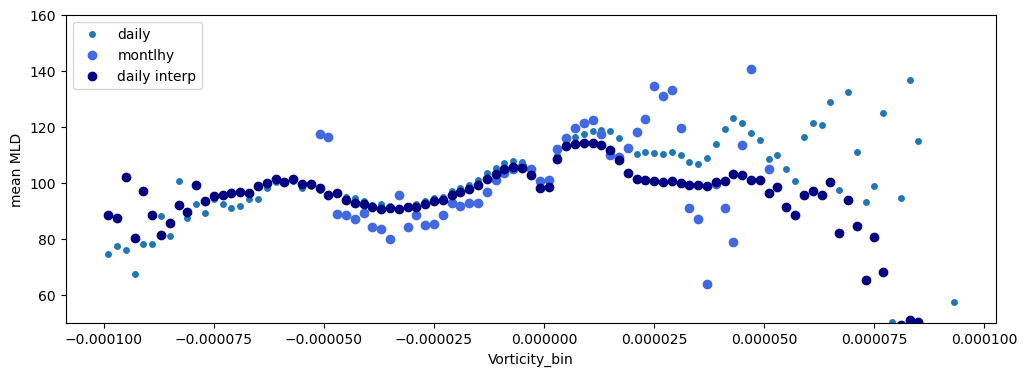

In [244]:
plt.figure(figsize = (12,4))
ζ01intoMLD.mean('time').plot.scatter(label='daily',zorder=0)
ζ01intoMLD_monthly.mean('time').plot.scatter(color='royalblue',label='montlhy')
ζ01intoMLD_daily_interp.mean('time').plot.scatter(color='navy',label='daily interp')
plt.legend()
plt.ylabel('mean MLD')
plt.ylim(50,160)

It seems to me that using either daily or daily interpolated data of MLD works. Monthly data not so much because the end tails of vorticity kind of get shrinked

Text(0.5, 1.0, 'Mixed layer depth average per vorciticy bin')

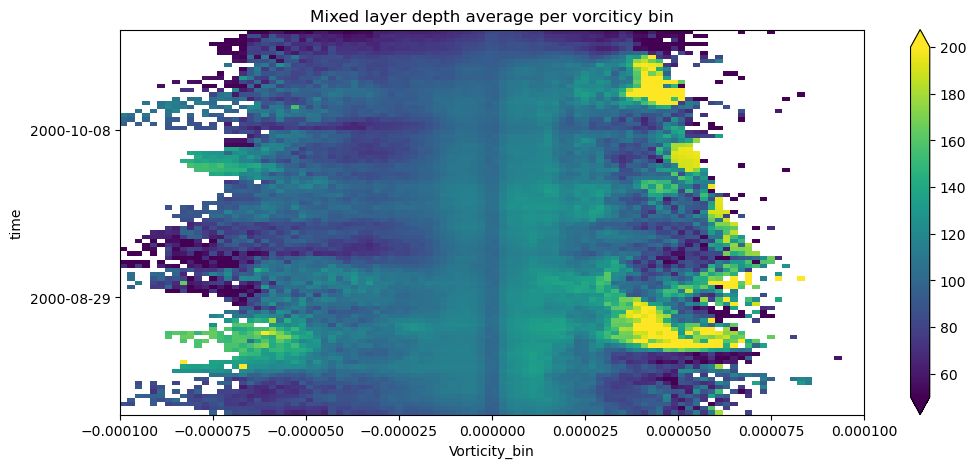

In [245]:
plt.figure(figsize=(12,5))
ζ01intoMLD.plot(vmin=50,vmax=200)
plt.title('Mixed layer depth average per vorciticy bin')

We do see lower MLDs in location of negative, anticyclonc vorticity. So perhaps the model indeed represnts the Eddy ICe Pumping

Text(0, 0.5, 'Normalized')

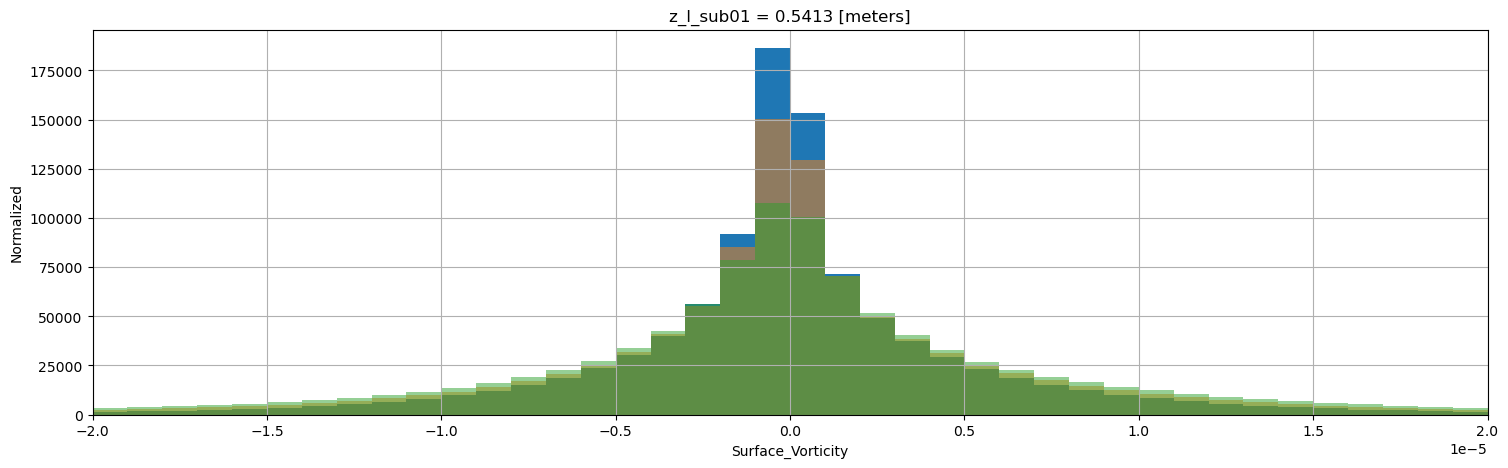

In [169]:
bin_edges_refined = np.linspace(-1e-4,1e-4,201)
plt.figure(figsize=(18,5))
ζ_01.cf.sel(latitude=Edge_lat_slice).plot.hist(bins=bin_edges_refined, density=True)
ζ_005.cf.sel(latitude=Edge_lat_slice).plot.hist(bins=bin_edges_refined, density=True,alpha=0.5)
ζ_0025.cf.sel(latitude=Edge_lat_slice).plot.hist(bins=bin_edges_refined, density=True,alpha=0.5)
plt.xlim(-2e-5,2e-5)
plt.grid()
plt.ylabel('Normalized')

The plot seem to imply that we have a distribution of stronger vorticity values in higher resolutions, which could indeed lead to stronger friction with sea ice and perhaps stronger EIP

In [157]:
ζ_005_SIedge = ζ_005.cf.sel(latitude=Edge_lat_slice) * panant005_SIC_mask#masked where thre is no sea ice
ζ_005_SIedge.name = 'Vorticity'

ζ_0025_SIedge = ζ_0025.cf.sel(latitude=Edge_lat_slice) * panant0025_SIC_mask#masked where thre is no sea ice
ζ_0025_SIedge.name = 'Vorticity'


In [158]:
#making all patrices the same size, so the larger areas of the coarse model doesnt bias the values
ζ_01_SIedge_into0025 = ζ_01_SIedge.interp(xq=ζ_0025_SIedge.xq,yq=ζ_0025_SIedge.yq)
ζ_005_SIedge_into0025 = ζ_005_SIedge.interp(xq=ζ_0025_SIedge.xq,yq=ζ_0025_SIedge.yq)

In [159]:
ζ_01_into0025 = ζ_01.interp(xq=ζ_0025.xq,yq=ζ_0025.yq)
ζ_005_into0025 = ζ_005.interp(xq=ζ_0025.xq,yq=ζ_0025.yq)

plot below uses model outputs with the interpolated grid, but the different running grids

Text(0, 0.5, 'Number of grid points')

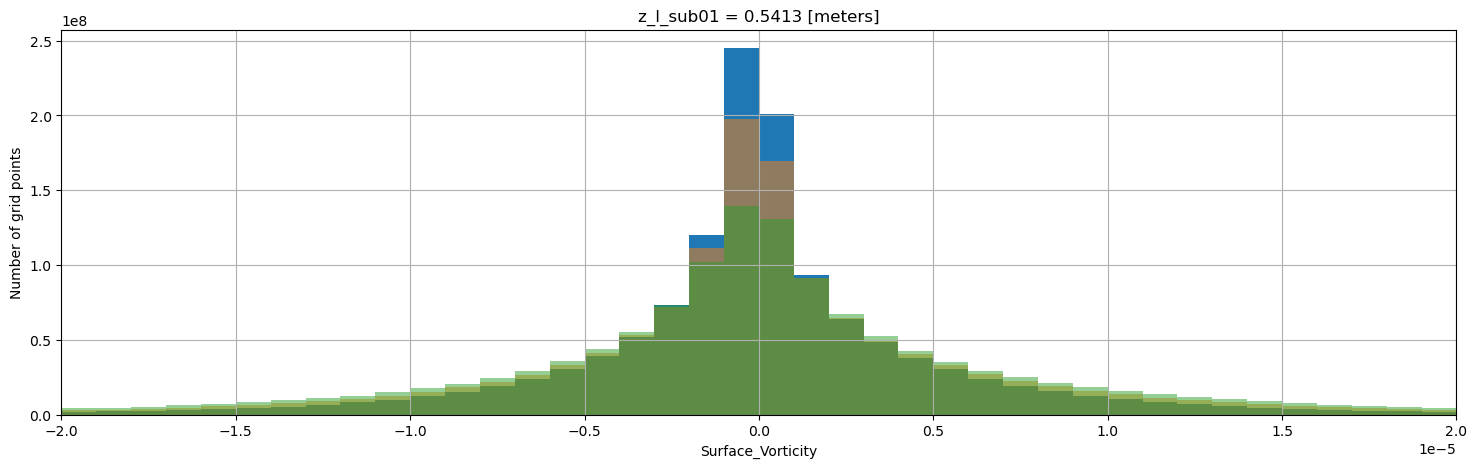

In [170]:
plt.figure(figsize=(18,5))
ζ_01_into0025.sel(yq=Edge_lat_slice).plot.hist(bins=bin_edges_refined)
ζ_005_into0025.sel(yq=Edge_lat_slice).plot.hist(bins=bin_edges_refined,alpha=0.5)
ζ_0025.cf.sel(latitude=Edge_lat_slice).plot.hist(bins=bin_edges_refined,alpha=0.5)
plt.xlim(-2e-5,2e-5)
plt.grid()
plt.ylabel('Number of grid points')

The number of grid points for the plot above is the same for all resolutions, as we have interpolted all models vorticity output into the 1/40th grid. ANd the result here is the same, confirming what we've seen above

## Vorticity direction and resolution



DOes the higher vorticity in higher resolutions alter the MLD, and eddy ice pumping? LEt's see how the MLD changes in each resolution across different vorticity values, and how the sea ice changes too

(70.0, 120.0)

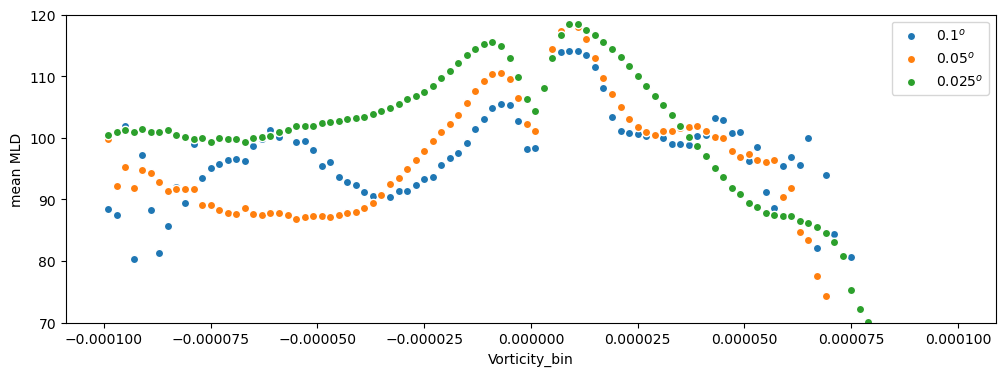

In [235]:
plt.figure(figsize = (12,4))
ζ01intoMLD_daily_interp.mean('time').plot.scatter(x='Vorticity_bin',zorder=0,label = r'$0.1^o$')
ζ005intoMLD_daily_interp.mean('time').plot.scatter(label = r'$0.05^o$')
ζ0025intoMLD_daily_interp.mean('time').plot.scatter(label = r'$0.025^o$')
plt.legend()
plt.ylabel('mean MLD')
plt.ylim(70,120)


(0.0, 850.0)

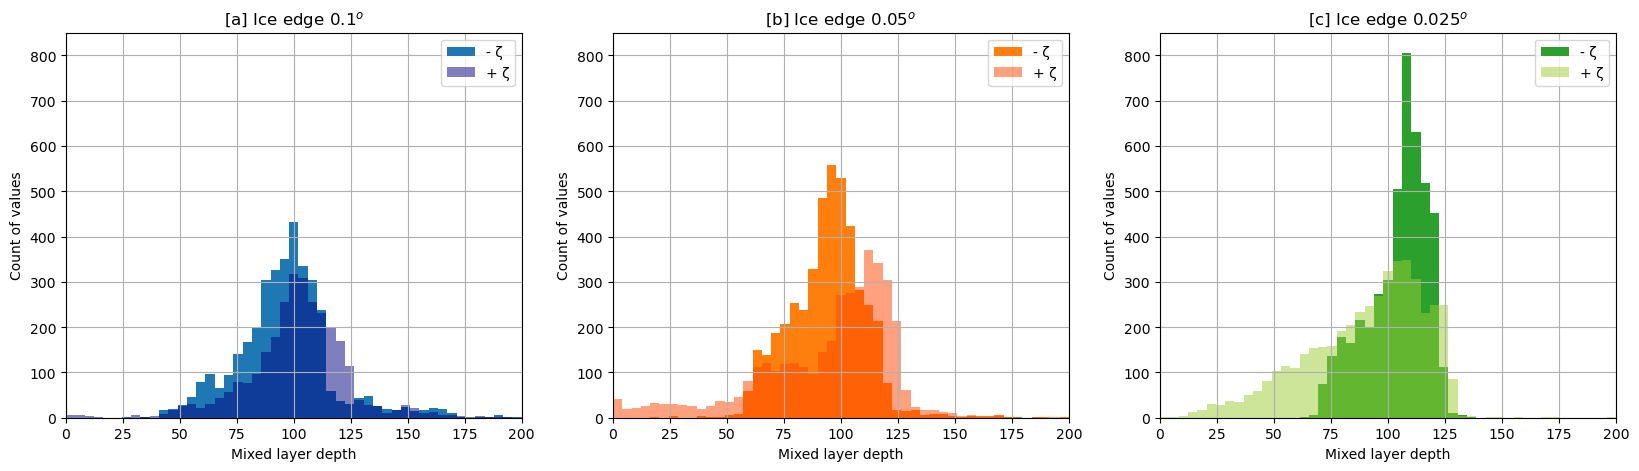

In [295]:
plt.figure(figsize=(20,5))
plt.subplot(1,3,1)
ζ01intoMLD_daily_interp.sel(Vorticity_bin=slice(-1,0)).plot.hist(bins=np.linspace(0,200),label='- ζ')
ζ01intoMLD_daily_interp.sel(Vorticity_bin=slice(0,1)).plot.hist(color='navy',bins=np.linspace(0,200),alpha=.5,label='+ ζ')
plt.legend()
plt.xlabel('Mixed layer depth')
plt.ylabel('Count of values')
plt.title(r'[a] Ice edge $0.1^o$')
plt.grid()
plt.xlim(0,200)
plt.ylim(0,850)

plt.subplot(1,3,2)
ζ005intoMLD_daily_interp.sel(Vorticity_bin=slice(-1,0)).plot.hist(bins=np.linspace(0,200),label='- ζ',color='tab:orange')
ζ005intoMLD_daily_interp.sel(Vorticity_bin=slice(0,1)).plot.hist(color='orangered',bins=np.linspace(0,200),alpha=.5,label='+ ζ')
plt.legend()
plt.xlabel('Mixed layer depth')
plt.ylabel('Count of values')
plt.title(r'[b] Ice edge $0.05^o$')
plt.grid()
plt.xlim(0,200)
plt.ylim(0,850)

plt.subplot(1,3,3)
ζ0025intoMLD_daily_interp.sel(Vorticity_bin=slice(-1,0)).plot.hist(bins=np.linspace(0,200),label='- ζ',color='tab:green')
ζ0025intoMLD_daily_interp.sel(Vorticity_bin=slice(0,1)).plot.hist(color='yellowgreen',bins=np.linspace(0,200),alpha=.5,label='+ ζ')
plt.legend()
plt.xlabel('Mixed layer depth')
plt.ylabel('Count of values')
plt.title(r'[c] Ice edge $0.025^o$')
plt.grid()
plt.xlim(0,200)
plt.ylim(0,850)

We see negative vorticity bins curve skwewed towards lower MLDs compared to the positive vorticity curves in both the $0.1^o$ and $0.05^o$ model. This doesnt happen on the $0.025^o$. Instead, what seems to happen in the MLD high end tail of MLD of the $0.025^o$ model is that all high mixed layer depth values (MLD>150) seem to disapear. This also happens in the lower resolution models, but to a lower degree. Since that happens in both cyclonic and anticyclonic eddies, Im a little less sure this is driven by EIP.

Finally, notice that I didnt separate true eddies from circulation features with high vorticity. So there is no way to make sure these results are not influenced by large scale circulation

(0.0, 160.0)

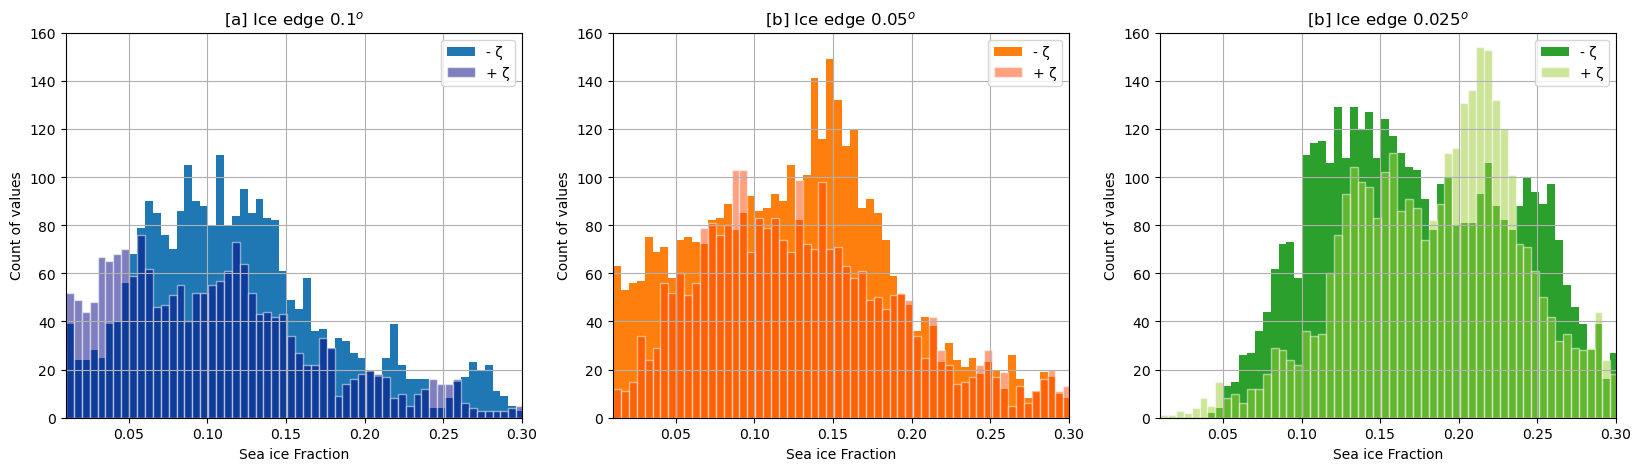

In [302]:
plt.figure(figsize=(20,5))
plt.subplot(1,3,1)
ζ01intoSIF_daily_interp.sel(Vorticity_bin=slice(-1,0)).plot.hist(bins=np.linspace(0,1,200),label='- ζ')
ζ01intoSIF_daily_interp.sel(Vorticity_bin=slice(0,1)).plot.hist(color='navy',edgecolor='white',bins=np.linspace(0,1,200),alpha=.5,label='+ ζ')
plt.legend()
plt.xlabel('Sea ice Fraction')
plt.ylabel('Count of values')
plt.title(r'[a] Ice edge $0.1^o$')
plt.grid()
plt.xlim(0.01,0.3)
plt.ylim(0,160)


plt.subplot(1,3,2)
ζ005intoSIF_daily_interp.sel(Vorticity_bin=slice(-1,0)).plot.hist(bins=np.linspace(0,1,200),label='- ζ',color='tab:orange')
ζ005intoSIF_daily_interp.sel(Vorticity_bin=slice(0,1)).plot.hist(color='orangered',edgecolor='white',bins=np.linspace(0,1,200),alpha=.5,label='+ ζ')
plt.legend()
plt.xlabel('Sea ice Fraction')
plt.ylabel('Count of values')
plt.title(r'[b] Ice edge $0.05^o$')
plt.grid()
plt.xlim(0.01,0.3)
plt.ylim(0,160)

plt.subplot(1,3,3)
ζ0025intoSIF_daily_interp.sel(Vorticity_bin=slice(-1,0)).plot.hist(bins=np.linspace(0,1,200),label='- ζ',color='tab:green')
ζ0025intoSIF_daily_interp.sel(Vorticity_bin=slice(0,1)).plot.hist(color='yellowgreen',edgecolor='white',bins=np.linspace(0,1,200),alpha=.5,label='+ ζ')
plt.legend()
plt.xlabel('Sea ice Fraction')
plt.ylabel('Count of values')
plt.title(r'[b] Ice edge $0.025^o$')
plt.grid()
plt.xlim(0.01,0.3)
plt.ylim(0,160)

Once again here, the 1/40th seem to behave in a slightly different way the the lower resolutions. At best, I can say it doesnt seem like the rotation direction have a clear impact on MLD when we get to the 1/40th. Perhaps what happens is that we just have more eddies migrating horizontally towards the sea ice edge, which then brings more heat horizontally towards thesea ice edge

In [310]:
ζ01intoSIF_daily_interp.sel(Vorticity_bin=slice(-1,0)).mean('Vorticity_bin').mean('time'),\
ζ01intoSIF_daily_interp.sel(Vorticity_bin=slice(0,1)).mean('Vorticity_bin').mean('time')

(<xarray.DataArray ()> Size: 8B
 array(0.14605365),
 <xarray.DataArray ()> Size: 8B
 array(0.12658319))

In [311]:
ζ005intoSIF_daily_interp.sel(Vorticity_bin=slice(-1,0)).mean('Vorticity_bin').mean('time'),\
ζ005intoSIF_daily_interp.sel(Vorticity_bin=slice(0,1)).mean('Vorticity_bin').mean('time')

(<xarray.DataArray ()> Size: 8B
 array(0.15211793),
 <xarray.DataArray ()> Size: 8B
 array(0.23310295))

In [312]:
ζ0025intoSIF_daily_interp.sel(Vorticity_bin=slice(-1,0)).mean('Vorticity_bin').mean('time'),\
ζ0025intoSIF_daily_interp.sel(Vorticity_bin=slice(0,1)).mean('Vorticity_bin').mean('time')

(<xarray.DataArray ()> Size: 8B
 array(0.21386883),
 <xarray.DataArray ()> Size: 8B
 array(0.29774729))

I guess the remaining question is, can we separate how much of the increase in MHT come from Eddies, and how much comes from mean scale?